# Лабораторная работа №1 (19 марта 2026)

## 1. Начало работы

Перед началом работы загружаю все необходимые библиотеки: 

In [118]:
import re  # Для работы с регулярными выражениями
import nltk  # Для работы с текстом
from nltk.corpus import stopwords  # Для удаления стоп-слов
nltk.download('stopwords') 
from collections import Counter  # Для подсчета частоты элемементов
import matplotlib.pyplot as plt  # Для визуализации
from pymorphy3 import MorphAnalyzer  
import spacy
import requests
import numpy as np
import pandas as pd
from wordcloud import WordCloud 
from sklearn.feature_extraction.text import TfidfVectorizer
from pymorphy3 import MorphAnalyzer 
morph = MorphAnalyzer()
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder
from nltk.metrics import BigramAssocMeasures, TrigramAssocMeasures
import seaborn as sns
from spacy import displacy



[nltk_data] Downloading package stopwords to /Users/polya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Загружаю необходимый для работы файл: 

In [147]:
url = "https://raw.githubusercontent.com/polina03avdeevaa/Lab_1/refs/heads/main/1.txt"

response = requests.get(url)
text = response.text

Так как текст загрузился и отображается, судя по всему, корректно, начинаю работу с ним. 

____

## 2. Предобработка текста

Так как в тексте есть оглавление и разбивка на условные части, кажется, их лучше удалить, чтобы они не создавали шум при анализе. 

In [120]:
text = re.sub(r'ПОСЫЛКА\s+[А-ЯЁ]+', '', text)
text = re.sub(r'ЛЮБОВ\w+\s+КЪ\s+СЛОВОХОТ\w+', '', text)
text = re.sub(r'СЛОВОХОТ\w+\s+КЪ\s+ЛЮБОВ\w+', '', text)

In [121]:
text

'НЯНЮШКАМЪ\r\nи\r\nМАМУШКАМЪ\r\nблагодушнѣйше посвящаетъ\r\n\r\nБезлестный почитателъ ихъ\r\nВ. Б.\r\n\r\n  \r\nОГЛАВЛЕНІЕ.\r\n\r\n   Благодушнѣйшее посвященіе сей книги Нянюшкамъ и Мамушкамъ\r\n   Письмо ЛЮБОВѢДА къ СЛОВОХОТУ, въ которомъ съ восхищеніемъ описывая распространившееся нынѣ повсюду просвѣщеніе и умножившійся торгъ книгами, проситъ онъ о сообщеніи ему Гисторическихъ преданій о достославныхъ Пошехонцахъ, кои, по мнѣнію его, можно смѣло издашь въ свѣтъ для забавы читателей\r\n   Отвѣтъ СЛОВОХОТА къ ЛЮБОВѢДУ, въ которомъ похваляя намѣреніе его издать въ свѣтъ сказанія о Пошехонскихъ Вигаязахъ, соглашается присылать ему оныя\r\n   Посылка ПЕРВАЯ отъ СЛОВОХОТА къ ЛЮБОВѢДУ, содержащая въ себѣ во первыхъ, торжественное шествіе Пошехонцевъ на поклонъ къ новому Воеводѣ и во вторыхъ, чудное и удивительное приключеніе съ рыбою Щукою, которую безкорыстный сей Воевода позволилъ Пошехонцамъ приносишь къ себѣ каждое утро\r\n   Посылка ВТОРАЯ, въ которой описывается сильное усердіе Пошехо

Судя по всему, текст написан до реформы 1918 года, из-за чего его нужно дополнительно обработать перед тем, как проводить токенизацию и лемматизацию. 

In [122]:
def normalize_old_russian(text):
    text = text.replace('ѣ', 'е')
    text = text.replace('і', 'и')
    text = text.replace('ѳ', 'ф')
    text = text.replace('ѵ', 'и')
    
    # убрать твердый знак на конце слов
    text = re.sub(r'ъ\b', '', text)
    
    return text

In [123]:
text = normalize_old_russian(text)

Теперь перехожу к основной предобработке текста: 

In [124]:
corpus = re.split(r'посылка\s*[а-яёa-z]?', text.lower())
stopwords_ru = stopwords.words('russian')

clean_texts = []
for text in corpus:
    text = re.sub(r'\n', ' ', text)
    text = re.sub('[^а-яА-ЯёЁ -]', '', text.lower())
    tokens = re.findall(r'\w+', text)  # Токенизация 
    lemmatized_text = [morph.parse(tok)[0].normal_form for tok in tokens]  # Лемматизация с помощью pymorphy3
    text_no_stop = [token for token in lemmatized_text if token.lower() not in stopwords_ru]  # Удаление стоп-слов
    text_no_stop = ' '.join(text_no_stop)
    clean_texts.append(text_no_stop)

print(clean_texts)

['нянюшкамъ мамушкамъ благодушнейший посвящать безлестный почитатеть б оглавлен благодушный посвящение сей книга нянюшка мамушка письмо любовда словохота который восхищение описывать распространиться ныне повсюду просвещение умножиться торг книга просить сообщение гисторический предание достославный пошехонец кой мнение смело издать свет забава читатель ответ словохота любовда который похвалять намерение издать свет сказание пошехонский вигаяз соглашаться присылать оный', 'ервать словохота любовда содержать первый торжественный шествие пошехонец поклон новый воевода второй чудной удивительный приключение рыба щука который безкорыстный сей воевода позволить пошехонец приносить каждый утро', 'торая который описываться сильный усердие пошехонец посмотреть прославляемый весь московския диковинка сперьва пошехонский колокольня высокий', 'ретья пошехонец удовлетворить колокольня пламеннагой свой желание видеть москва решиться пуститься свой особа славный сей город лично обозреть красота', 'е

## 3. Анализ на разных уровнях

In [125]:
all_text = ' '.join(clean_texts)
tokens = [word for word in all_text.split() if len(word) > 3]  # Фильтрую слова, чтобы не выводились совсем короткие

freq = Counter(tokens)
top_30 = freq.most_common(30)

print(top_30)

[('свой', 434), ('весь', 206), ('сказать', 98), ('однако', 80), ('видеть', 75), ('дело', 74), ('знать', 67), ('хороший', 67), ('мочь', 65), ('слово', 64), ('рука', 63), ('глаз', 59), ('говорить', 58), ('время', 56), ('голова', 56), ('человек', 55), ('самый', 52), ('надобный', 49), ('место', 49), ('нога', 46), ('друг', 45), ('хотя', 44), ('стать', 44), ('который', 43), ('сторона', 41), ('день', 41), ('хозяин', 41), ('оный', 40), ('первый', 40), ('нибыть', 40)]


Вывожу результат в виде таблицы: 

In [126]:
df_lab1 = pd.DataFrame(top_30, columns=['word', 'frequency'])

In [127]:
df_lab1.head(10)

,word,frequency
0,свой,434
1,весь,206
2,сказать,98
3,однако,80
4,видеть,75
5,дело,74
6,знать,67
7,хороший,67
8,мочь,65
9,слово,64


Так как теперь не попадаются совсем короткие слова типа «мой», «сей» и так далее, результат получился более интересный. Построю из него облако слов и напишу первые наблюдения по тексту. 

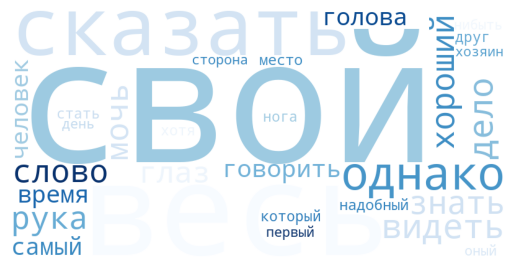

In [128]:
word_cloud_dict = dict(top_30) # Создаю словарь, иначе будет возникать ошибка

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap="Blues"
).generate_from_frequencies(word_cloud_dict)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

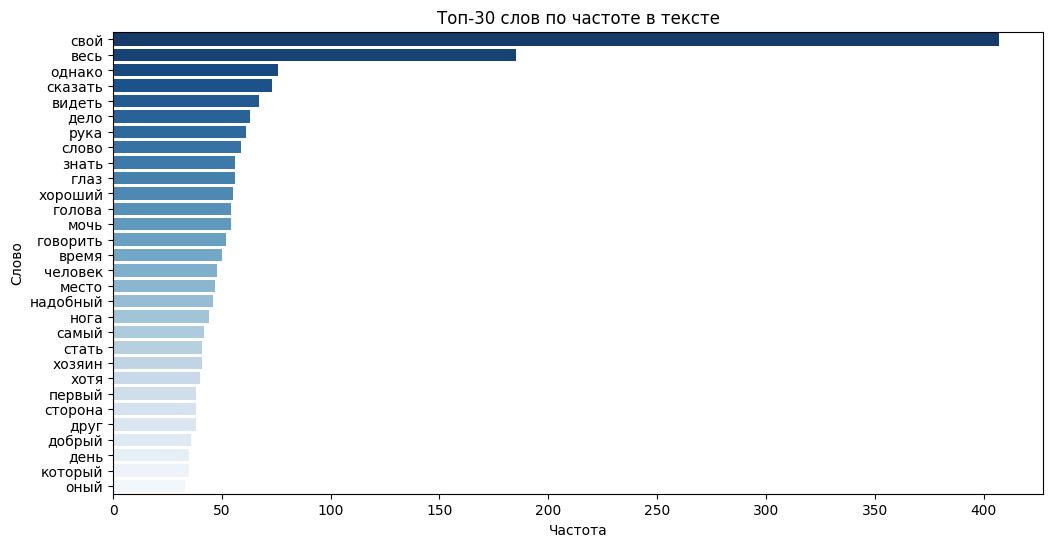

In [129]:
df_plot = pd.DataFrame({
    "word": words,
    "frequency": frequencies
})

plt.figure(figsize=(12, 6))
sns.barplot(x="frequency", 
            y="word", 
            data=df_plot, 
            palette="Blues_r",
            hue="word", 
            dodge=False, 
            legend=False)
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.title("Топ-30 слов по частоте в тексте")
plt.show()

Пока что сложно точно сказать, что за текст передо мной. Кажется, что это что-то вроде наставлений или переписки. На это указывают слова типа: «стать», «хороший», «дело», «говорить», «мочь», «добрый», «друг». Но нужно провести еще анализ.

In [130]:
bigram_finder = BigramCollocationFinder.from_words(tokens)

bigram_finder.apply_freq_filter(2)  # Только биграммы, которые встречаются больше двух раз

top_bigrams = bigram_finder.nbest(BigramAssocMeasures.pmi, 30)
top_bigrams

[('лорд', 'милорд'),
 ('луковый', 'перие'),
 ('неумение', 'грамота'),
 ('пожалуста', 'сойдци'),
 ('прервать', 'разглагольствие'),
 ('сидоров', 'коза'),
 ('указательный', 'перст'),
 ('утёнок', 'гусёнок'),
 ('дядя', 'герасим'),
 ('захворать', 'лихоманка'),
 ('перваго', 'взгляд'),
 ('померанец', 'лимон'),
 ('предание', 'достославный'),
 ('прошлец', 'всесветный'),
 ('семья', 'урод'),
 ('сложиться', 'складчина'),
 ('гидра', 'лернейский'),
 ('креститься', 'творить'),
 ('обряд', 'поминовение'),
 ('осьмить', 'копейка'),
 ('светскаго', 'обхождение'),
 ('сказка', 'сказываться'),
 ('восемь', 'девять'),
 ('двое', 'трое'),
 ('добренький', 'хозяюшка'),
 ('ушко', 'смеяться'),
 ('цервяк', 'цервяк'),
 ('василий', 'кузнец'),
 ('достоверный', 'утверждать'),
 ('кожа', 'подирать')]

Ага! Здесь уже что-то интересное получается! 

На данном этапе становится понятно, что среди коллокаций попадаются и фразеологизмы, например: «сидоров» + «коза» = «Драть как сидорову козу», а также мифические названия: «Гидра» + «Лернейский» = «Лернейская гидра». 

Посмотрю, что получается в триграммах: 


In [131]:
trigram_finder = TrigramCollocationFinder.from_words(tokens)
trigram_finder.apply_freq_filter(2)

top_trigrams = trigram_finder.nbest(TrigramAssocMeasures.pmi, 30)
top_trigrams

[('цыплёнок', 'утёнок', 'гусёнок'),
 ('креститься', 'творить', 'молитва'),
 ('знание', 'светскаго', 'обхождение'),
 ('выкидывать', 'разный', 'штука'),
 ('предание', 'достославный', 'пошехонец'),
 ('связать', 'крепко', 'накрепко'),
 ('взять', 'ложка', 'кисель'),
 ('родитель', 'сродник', 'друг'),
 ('человек', 'восемь', 'девять'),
 ('сбыть', 'рука', 'долой'),
 ('мочь', 'удержаться', 'смех'),
 ('найти', 'коса', 'камень'),
 ('вселиться', 'нечистый', 'далее'),
 ('видеть', 'проклятый', 'зелье'),
 ('исполнение', 'свой', 'проект'),
 ('повесить', 'свой', 'буйный'),
 ('сделать', 'первый', 'доставлять'),
 ('спустя', 'несколько', 'время'),
 ('удалой', 'добрый', 'молодец'),
 ('двор', 'двор', 'улица'),
 ('дело', 'мастер', 'бояться'),
 ('свой', 'родимый', 'сторонушка'),
 ('пойти', 'свой', 'черёд'),
 ('свой', 'буйный', 'головушка'),
 ('каковой', 'пора', 'время'),
 ('приняться', 'исполнение', 'свой'),
 ('кричать', 'весь', 'горло'),
 ('слишком', 'надеяться', 'свой'),
 ('всякий', 'дело', 'мастер'),
 ('дру

Здесь вновь встречаются фразеологизмы типа: 
1. ('найти', 'коса', 'камень') = «Нашла коса на камень»; 
2. ('пойти', 'свой', 'черёд') = «Идти своим чередом»; 
3. ('кричать', 'весь', 'горло') = «Кричать во все горло». 

Пословицы: 
1. ('дело', 'мастер', 'бояться') = «Дело мастера боится»

Я все равно пока склоняюсь к тому, что этот текст содержит в себе какие-то притчи. На это указывают наставляющие фразеологизмы и пословицы, как бы указывающие на то, что нужно действовать, чтобы чего-то добиться, а также коллокации по типу: 

1. ('креститься', 'творить', 'молитва') — может указывать на необходимость в молитвах; 
2. ('знание', 'светскаго', 'обхождение') — может указывать на необходимость в умении держать себя в обществе; 
3. ('исполнение', 'свой', 'проект') — может указывать на необходимость в занятии своим делом; 
4. ('всякий', 'дело', 'мастер') — может указывать на человека, который мастерски справляется со своими задачами. 

Посмотрю также на морфологию текста:

In [132]:
pos_counts = Counter()

for word in tokens:
    parsed = morph.parse(word)[0]
    if parsed.tag.POS:
        pos_counts[parsed.tag.POS] += 1

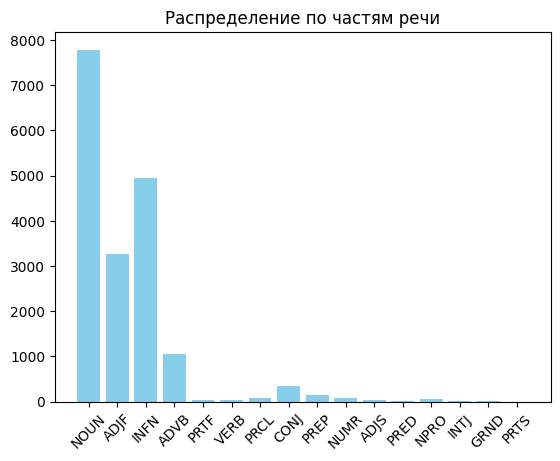

In [133]:
plt.bar(pos_counts.keys(), pos_counts.values(), color = "skyblue")
plt.title("Распределение по частям речи")
plt.xticks(rotation=45)
plt.show()

В тексте больше всего существительных (NOUN) и инфинитивной формы глаголов (INFN), что в целом может указывать на повествовательный или поучительный текст. Особенно на эту мысль наталкивают, конечно, инфинитивы. 

In [134]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(clean_texts)
len(vectorizer.get_feature_names_out())

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=1)
X = tfidf_vectorizer.fit_transform(clean_texts)
text_vector = pd.DataFrame(columns = tfidf_vectorizer.get_feature_names_out(), data = X.toarray())
text_vector

,абдерита,авангардия,автор,агафон,агафонович,агафоныцть,ад,адамантовый,адеевич,адеевне,...,ясный,ястреб,ясынька,ятая,ятнадцатый,ячмень,яшка,ящик,ёж,ёму
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.294352,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [143]:
# Оставляю только топ-25 слов, чтобы не перегружать визуализацию
top_n = 25

top_words = text_vector.mean().sort_values(ascending=False).head(top_n).index
reduced_matrix = text_vector[top_words]

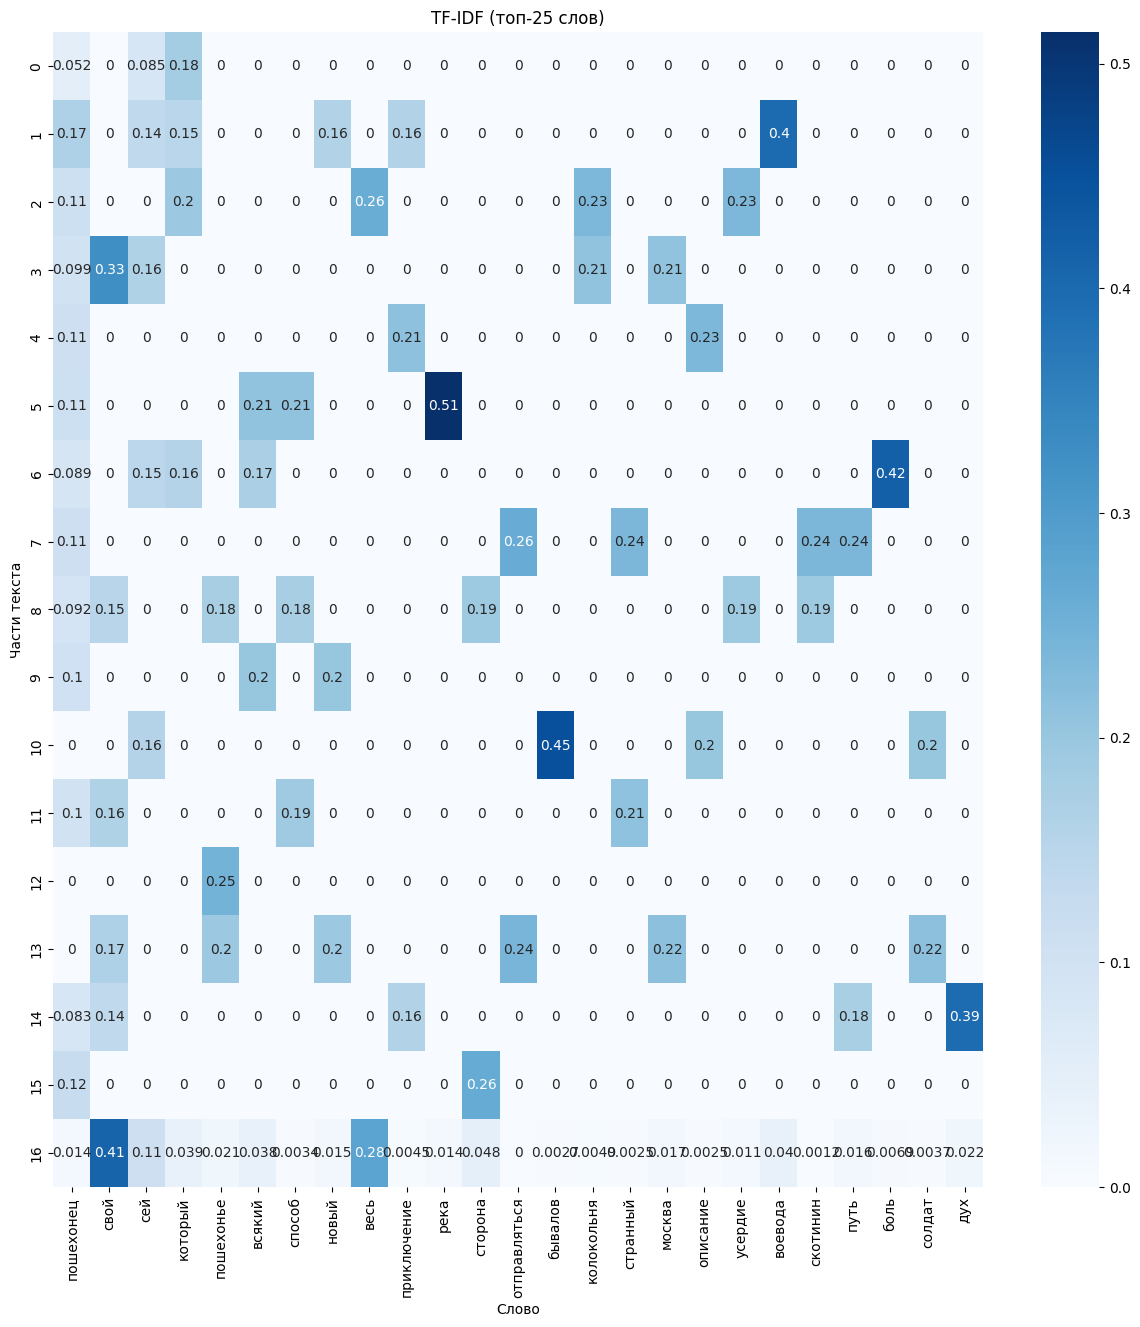

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(reduced_matrix, cmap='Blues', annot=True)

plt.title("TF-IDF (топ-25 слов)")
plt.xlabel("Слово")
plt.ylabel("Части текста")

plt.show()

На тепловой карте видно, что многие слова, несмотря на высокую частотность употребления (на что указывает фильтрация топ-25 слов) на самом деле не являются равномерно распределёнными по всему произведению, так как  в опредеделенных частях текста имеют значение 0. 

Подобный результат также может указывать на то, что я имею дело с раздробленными «Посылками», содержащими в себе какие-то наставления на разные темы. 

## 4. Результат

Итак, если судить по тому, что получилось выявить в тексте, передо мной: 

1. Текст, написанный до 1918 года. Кажется даже, что *далеко* до 1918 года... 
2. Текст содержит в себе как бы отдельные письма (?), содержащие в себе притчи или отдельные наставления. То есть по сути, это что-то вроде сборника текстов. 
3. Автор текста, если судить по коллокациям, использует фразеологизмы и поговорки, что может добавлять произведению эмоциональной выразительности. Как мне кажется, это делает текст доступным, возможно, добавляет ему какой-то ироничности. То есть скорее всего это не какой-то текст, написанный "высокопарным" слогом, но, конечно, я могу ошибаться :)  